In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [2]:
def read_txt(filename):
    with open(filename, encoding='utf-8') as f:
        lines = f.readlines()
    start = 0
    for i, line in enumerate(lines):
        if '06.10.2025' in line:
            start = i + 2
        
            break
    
    colnames = ['Time', 'Amplitude']
    
    df = pd.read_csv(
        filename,
        sep='\t',
        skiprows=start,
        skipinitialspace=True,
        names=colnames,
        engine='python'
    )

    return df['Time'].values, df['Amplitude'].values

In [3]:
def calculate_conc(v0, dose, conc0, iterations=5):
    """
    v0 - изначальный объем воды
    dose - объем приливаемой соли на каждой итерации
    conc0 - концентрация соли в стоковом растворе
    iterations - количество добавлений соли
    
    Возвращает концентрации после каждого добавления в μM
    """    
    conc = [0 for _ in range(iterations)]
    
    for i in range(iterations):
        vol = (v0 * 1e-3) + ((i+1) * dose * 1e-6)
        mole = ((i+1) * dose * 1e-6) * conc0
        conc[i] = mole / vol
        
    return np.array(conc) * 1e6

In [4]:
MN_C0 = 0.04 # in M
CU_C0 = 0.25 # in M
V0 = 25 # in ml
MN_Dose = 10 # in μl
CU_Dose = 100 # in μl
iterations = 5

mn_conc = calculate_conc(V0, MN_Dose, MN_C0)
cu_conc = calculate_conc(V0, CU_Dose, CU_C0)

# Зависимость амплитуды намагниченности от длительности сигнала

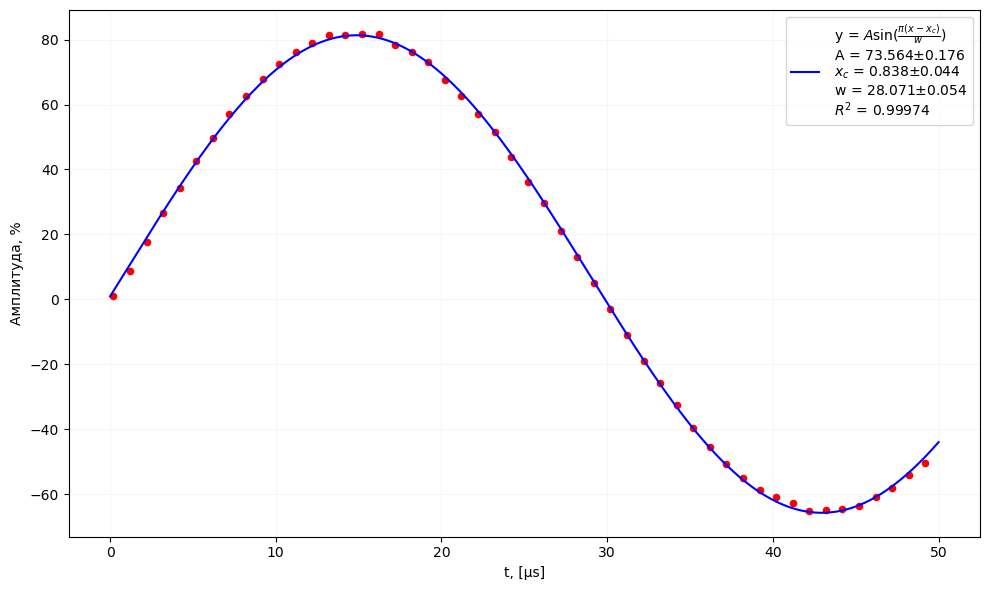

In [10]:
pulse_x, pulse_y = read_txt('AMG_NMR/pulses10mhz.txt')

def sine_approx(x, shift, amp, xc, w):
    return shift + amp * np.sin((np.pi * (x - xc)) / w)

popt, pcov = curve_fit(sine_approx, pulse_x, pulse_y, p0=[0, 70, 0, 25])
shift, amp, xc, w = popt
shift_error, amp_err, xc_err, w_err = np.sqrt(np.diag(pcov))


x_array_pulse = np.linspace(0, 50, 1000)
y_array_pulse = sine_approx(pulse_x, shift, amp, xc, w)
pulse_r2 = r2_score(pulse_y, y_array_pulse)
y_array_pulse = sine_approx(x_array_pulse, shift, amp, xc, w)


plt.figure(figsize=(10, 6))
plt.scatter(pulse_x, pulse_y, c='r', s=20)
plt.plot(x_array_pulse, y_array_pulse, c='b', label=f' y = $A\sin(\\frac{{\pi(x - x_c)}}{{w}})$\n A = {amp:.3f}$\pm{amp_err:.3f}$\n $x_c$ = {xc:.3f}$\pm${xc_err:.3f}\n w = {w:.3f}$\pm{w_err:.3f}$\n $R^2$ = {pulse_r2:.5f}')

plt.grid(alpha=0.1)
plt.xlabel('t, [μs]')
plt.ylabel('Амплитуда, %')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
print('T_90 =', round(x_array_pulse[np.argmax(y_array_pulse)], 3), 'error =', round(np.sqrt(xc_err**2 + (w_err**2 / 4)), 2))
print('T_180 =', round(x_array_pulse[np.argmin(abs(y_array_pulse))], 3), 'error =', round(np.sqrt(xc_err**2 + w_err**2), 2))

T_90 = 14.865 error = 0.05
T_180 = 29.88 error = 0.07


In [12]:
def T2(x, c, t2):
    return c * np.exp(-x/t2)
    
def T1(x, c, t1):
    return c * (1 - np.exp(-x/t1))

# Оценка времени релаксации воды $T_2$

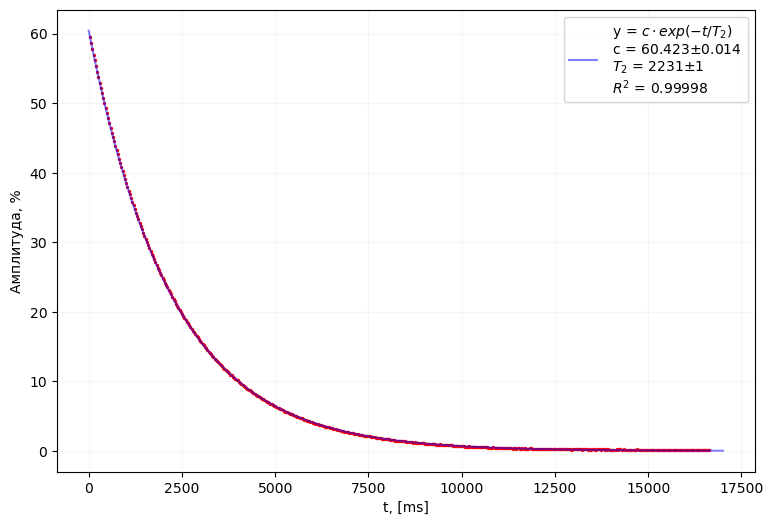

In [13]:
x_water_t2, y_water_t2 = read_txt('AMG_NMR/t2_cpmg_water.txt')

popt_water_t2, pcov_water_t2 = curve_fit(T2, x_water_t2, y_water_t2, p0=[65, 2500])
c_water_t2, t2_water_t2 = popt_water_t2
c_water_t2_error, t2_water_t2_error = np.sqrt(np.diag(pcov_water_t2))

x_array_water_t2 = np.linspace(0, 17000, 1000)
y_array_water_t2 = T2(x_water_t2, c_water_t2, t2_water_t2)
r2_water_t2 = r2_score(y_water_t2, y_array_water_t2)
y_array_water_t2 = T2(x_array_water_t2, c_water_t2, t2_water_t2)

plt.figure(figsize=(9, 6))
plt.scatter(x_water_t2, y_water_t2, c='r', s=2)
plt.plot(x_array_water_t2, y_array_water_t2, c='b', alpha=0.5, label=f' y = $c\cdot exp(-t/T_2)$\n c = {c_water_t2:.3f}$\pm${c_water_t2_error:.3f}\n $T_2$ = {round(t2_water_t2)}$\pm${round(t2_water_t2_error)}\n $R^2$ = {r2_water_t2:.5f}')
plt.xlabel('t, [ms]')
plt.ylabel('Амплитуда, %')
plt.legend()
plt.grid(alpha=0.1)
plt.show()

# Оценка времени релаксации воды $T_1$

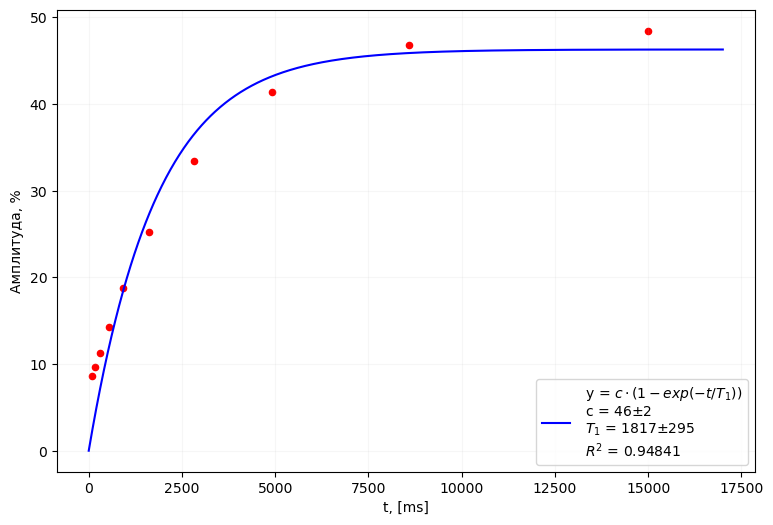

In [14]:
x_water_t1, y_water_t1 = read_txt('AMG_NMR/t1_sr_water.txt')

popt_water_t1, pcov_water_t1 = curve_fit(T1, x_water_t1, y_water_t1, p0=[60, 3000])
c_water_t1, t1_water_t1 = popt_water_t1
c_water_t1_error, t1_water_t1_error = np.sqrt(np.diag(pcov_water_t1))

x_array_water_t1 = np.linspace(0, 17000, 1000)
y_array_water_t1 = T1(x_water_t1, c_water_t1, t1_water_t1)
r2_water_t1 = r2_score(y_water_t1, y_array_water_t1)
y_array_water_t1 = T1(x_array_water_t1, c_water_t1, t1_water_t1)

plt.figure(figsize=(9, 6))
plt.scatter(x_water_t1, y_water_t1, c='r', s=20)
plt.plot(x_array_water_t1, y_array_water_t1, c='b', alpha=1, label=f' y = $c\cdot (1 - exp(-t/T_1))$\n c = {c_water_t1:.0f}$\pm${c_water_t1_error:.0f}\n $T_1$ = {round(t1_water_t1)}$\pm${round(t1_water_t1_error)}\n $R^2$ = {r2_water_t1:.5f}')
plt.xlabel('t, [ms]')
plt.ylabel('Амплитуда, %')
plt.legend()
plt.grid(alpha=0.1)
plt.show()

In [93]:
mn_color = [
    '#E6E6FA',  # Очень светлый фиолетовый
    '#D8BFD8',  # Светлый фиолетовый
    '#EE82EE',  # Средний фиолетовый
    '#DA70D6',  # Яркий фиолетовый
    '#8A2BE2'   # Темный фиолетовый
]

cu_color = [
    '#E6F7FF',  # Очень светлый голубой
    '#BAE7FF',  # Светлый голубой
    '#69C0FF',  # Средний голубой
    '#1890FF',  # Яркий голубой
    '#0050B3'   # Темный голубой
]

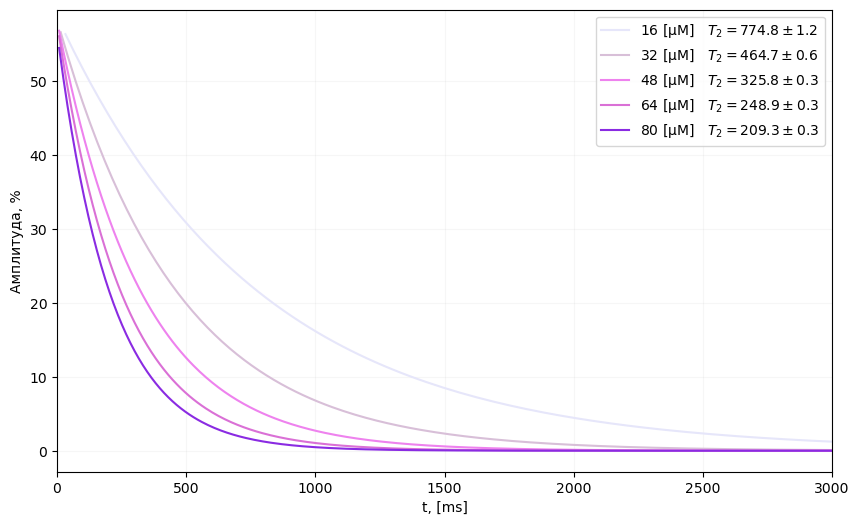

In [92]:
plt.figure(figsize=(10, 6))

T2ARRAY_MN = []
T2ARRAY_ERROR_MN = []

for i in range(iterations):
    x, y = read_txt(f'AMG_NMR/t2_cpmg_mn{i+1}.txt')
    
    popt, pcov = curve_fit(T2, x, y, p0=[58, 300])
    c_opt, t_opt = popt
    c_opt_error, t_opt_error = np.sqrt(np.diag(pcov))
    
    T2ARRAY_MN.append(t_opt)
    T2ARRAY_ERROR_MN.append(t_opt_error)
    
    plt.plot(x, T2(x, c_opt, t_opt), color=mn_color[i], label=f'{round(mn_conc[i])} [μM]$\quad T_2 = {round(t_opt, 1)}\pm{round(t_opt_error, 1)}$')
    
plt.xlim(0, 3000)
plt.legend()
plt.xlabel('t, [ms]')
plt.ylabel('Амплитуда, %')
plt.grid(alpha=0.1)
plt.show()

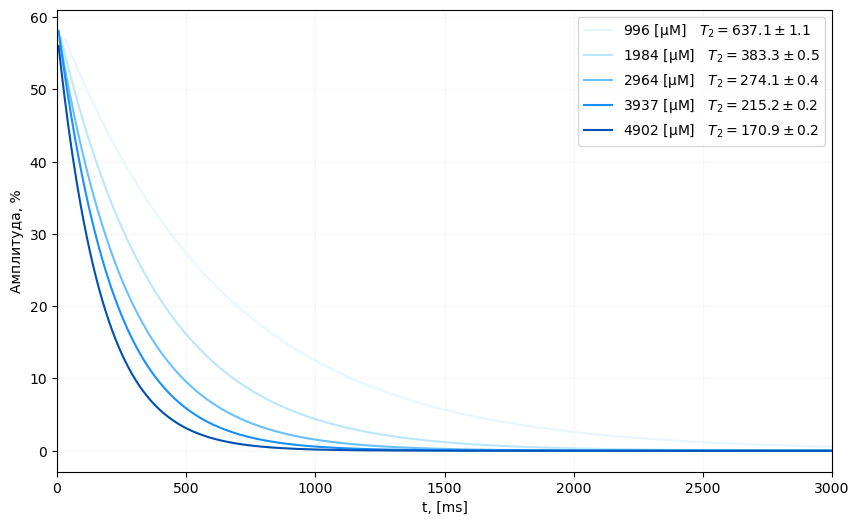

In [94]:
plt.figure(figsize=(10, 6))

T2ARRAY_CU = []
T2ARRAY_ERROR_CU = []

for i in range(iterations):
    x, y = read_txt(f'AMG_NMR/t2_cpmg_cu{i+1}.txt')
    
    popt, pcov = curve_fit(T2, x, y, p0=[58, 300])
    c_opt, t_opt = popt
    c_opt_error, t_opt_error = np.sqrt(np.diag(pcov))
    
    T2ARRAY_CU.append(t_opt)
    T2ARRAY_ERROR_CU.append(t_opt_error)
    
    plt.plot(x, T2(x, c_opt, t_opt), color=cu_color[i], label=f'{round(cu_conc[i])} [μM]$\quad T_2 = {round(t_opt, 1)}\pm{round(t_opt_error, 1)}$')
    
plt.xlim(0, 3000)
plt.legend()
plt.xlabel('t, [ms]')
plt.ylabel('Амплитуда, %')
plt.grid(alpha=0.1)
plt.show()

In [76]:
def sigma_conc(C_salt, V_salt, V_water, sigma_salt=1e-6, sigma_water=1e-3):
    return (C_salt / (V_salt + V_water)) * np.sqrt(V_water**2 * sigma_salt**2 + V_salt**2 * sigma_water**2)

In [81]:
mn_conc_error = [sigma_conc(MN_C0, MN_Dose*(i+1)*1e-6, V0*1e-3) for i in range(5)]
mn_conc_error = np.array(mn_conc_error) * 1e6
print(mn_conc_error)

cu_conc_error = [sigma_conc(CU_C0, CU_Dose*(i+1)*1e-6, V0*1e-3) for i in range(5)]
cu_conc_error = np.array(cu_conc_error) * 1e6
print(cu_conc_error)

[0.04306409 0.05118405 0.06240711 0.07535129 0.08926419]
[1.02666973 1.99956789 2.97470222 3.94468985 4.90808441]


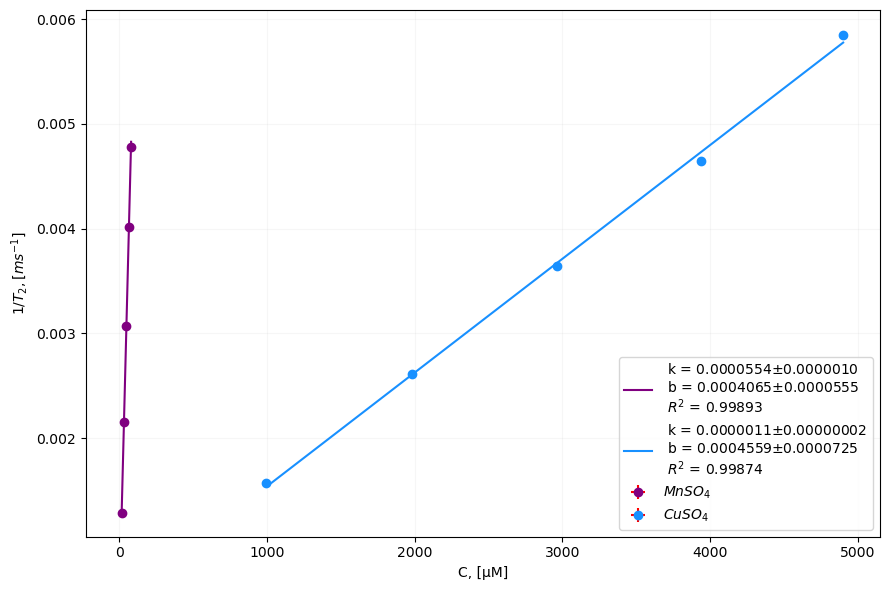

In [95]:
plt.figure(figsize=(9, 6))

def linear(x, a, b):
    return a * x + b

popt_mnt2, pcov_mnt2 = curve_fit(linear, mn_conc, 1/np.array(T2ARRAY_MN), p0=[1e-5, 1e-4])
k_mnt2, b_mnt2 = popt_mnt2
k_mnt2_er, b_mnt2_er = np.sqrt(np.diag(pcov_mnt2))
r2_mnt2 = r2_score(1/np.array(T2ARRAY_MN), linear(mn_conc, *popt_mnt2))
plt.plot(mn_conc, linear(mn_conc, *popt_mnt2), c='purple', label=f' k = {k_mnt2:.7f}$\pm${k_mnt2_er:.7f}\n b = {b_mnt2:.7f}$\pm${b_mnt2_er:.7f}\n $R^2$ = {r2_mnt2:.5f}')

plt.errorbar(x=mn_conc, y=1/np.array(T2ARRAY_MN), xerr=mn_conc_error, yerr=(np.array(T2ARRAY_ERROR_MN)/np.array(T2ARRAY_MN)**2), fmt='o', ecolor='red', c='purple', label='$MnSO_4$')
plt.errorbar(x=cu_conc, y=1/np.array(T2ARRAY_CU), xerr=cu_conc_error, yerr=(np.array(T2ARRAY_ERROR_CU)/np.array(T2ARRAY_CU)**2), fmt='o', ecolor='red', c='#1890FF', label='$CuSO_4$')

popt_cut2, pcov_cut2 = curve_fit(linear, cu_conc, 1/np.array(T2ARRAY_CU), p0=[1e-5, 1e-4])
k_cut2, b_cut2 = popt_cut2
k_cut2_er, b_cut2_er = np.sqrt(np.diag(pcov_cut2))
r2_cut2 = r2_score(1/np.array(T2ARRAY_CU), linear(cu_conc, *popt_cut2))
plt.plot(cu_conc, linear(cu_conc, *popt_cut2), c='#1890FF', label=f' k = {k_cut2:.7f}$\pm${k_cut2_er:.8f}\n b = {b_cut2:.7f}$\pm${b_cut2_er:.7f}\n $R^2$ = {r2_cut2:.5f}')


plt.xlabel('C, [μM]')
plt.ylabel('$1/T_2, [ms^{-1}]$')
plt.grid(alpha=0.1)
plt.tight_layout()
plt.legend()
plt.show()

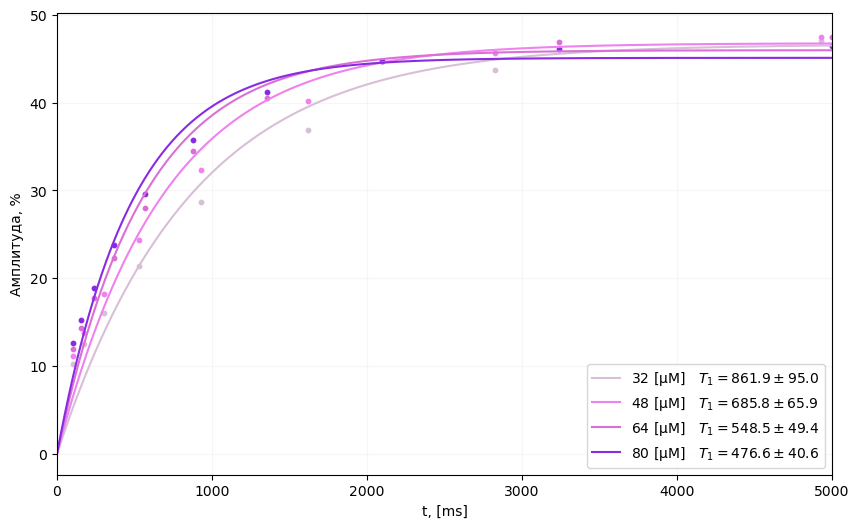

In [134]:
plt.figure(figsize=(10, 6))

X_FOR_T1 = np.linspace(0, 5000, 2500)

T1ARRAY_MN = []
T1ARRAY_ERROR_MN = []

for i in range(1, iterations):
    x, y = read_txt(f'AMG_NMR/t1_sr_mn{i+1}.txt')
    
    popt, pcov = curve_fit(T1, x, y, p0=[58, 300])
    c_opt, t_opt = popt
    c_opt_error, t_opt_error = np.sqrt(np.diag(pcov))
    
    T1ARRAY_MN.append(t_opt)
    T1ARRAY_ERROR_MN.append(t_opt_error)
    
    plt.plot(X_FOR_T1, T1(X_FOR_T1, c_opt, t_opt), color=mn_color[i], label=f'{round(mn_conc[i])} [μM]$\quad T_1 = {round(t_opt, 1)}\pm{round(t_opt_error, 1)}$')
    plt.scatter(x, y, s=10, c=mn_color[i])
    
plt.xlim(0, 5000)
plt.legend()
plt.xlabel('t, [ms]')
plt.ylabel('Амплитуда, %')
plt.grid(alpha=0.1)
plt.show()

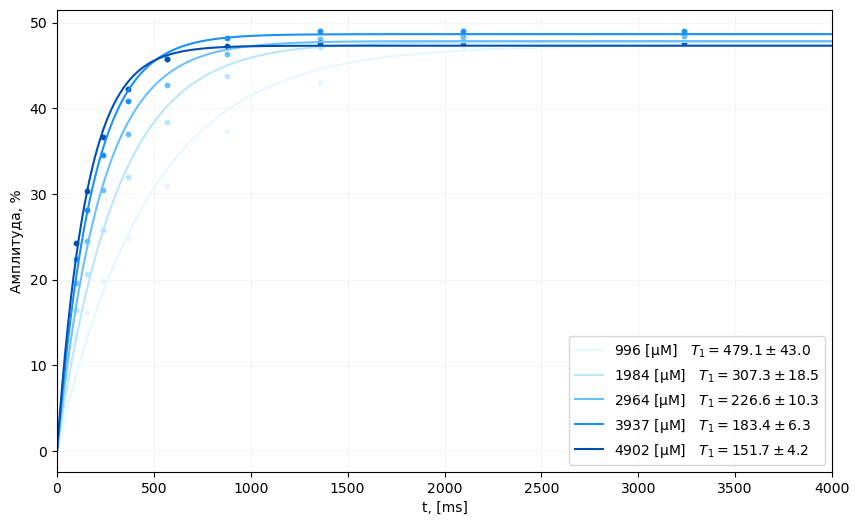

In [105]:
plt.figure(figsize=(10, 6))

X_FOR_T1 = np.linspace(0, 5000, 2500)

T1ARRAY_CU = []
T1ARRAY_ERROR_CU = []

for i in range(iterations):
    x, y = read_txt(f'AMG_NMR/t1_sr_cu{i+1}.txt')
    
    popt, pcov = curve_fit(T1, x, y, p0=[58, 300])
    c_opt, t_opt = popt
    c_opt_error, t_opt_error = np.sqrt(np.diag(pcov))
    
    T1ARRAY_CU.append(t_opt)
    T1ARRAY_ERROR_CU.append(t_opt_error)
    
    plt.plot(X_FOR_T1, T1(X_FOR_T1, c_opt, t_opt), color=cu_color[i], label=f'{round(cu_conc[i])} [μM]$\quad T_1 = {round(t_opt, 1)}\pm{round(t_opt_error, 1)}$')
    plt.scatter(x, y, s=10, c=cu_color[i])
    
plt.xlim(0, 4000)
plt.legend()
plt.xlabel('t, [ms]')
plt.ylabel('Амплитуда, %')
plt.grid(alpha=0.1)
plt.show()

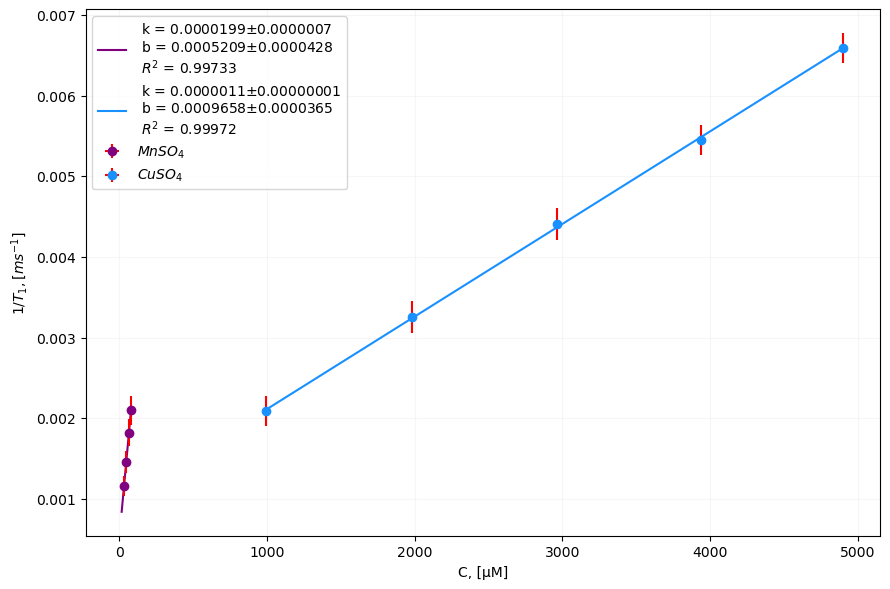

In [110]:
plt.figure(figsize=(9, 6))

def linear(x, a, b):
    return a * x + b

popt_mnt1, pcov_mnt1 = curve_fit(linear, mn_conc[1:], 1/np.array(T1ARRAY_MN), p0=[1e-5, 1e-4])
k_mnt1, b_mnt1 = popt_mnt1
k_mnt1_er, b_mnt1_er = np.sqrt(np.diag(pcov_mnt1))
r2_mnt1 = r2_score(1/np.array(T1ARRAY_MN), linear(mn_conc[1:], *popt_mnt1))
plt.plot(mn_conc, linear(mn_conc, *popt_mnt1), c='purple', label=f' k = {k_mnt1:.7f}$\pm${k_mnt1_er:.7f}\n b = {b_mnt1:.7f}$\pm${b_mnt1_er:.7f}\n $R^2$ = {r2_mnt1:.5f}')

plt.errorbar(x=mn_conc[1:], y=1/np.array(T1ARRAY_MN), xerr=mn_conc_error[1:], yerr=(np.array(T1ARRAY_ERROR_MN)/np.array(T1ARRAY_MN)**2), fmt='o', ecolor='red', c='purple', label='$MnSO_4$')
plt.errorbar(x=cu_conc, y=1/np.array(T1ARRAY_CU), xerr=cu_conc_error, yerr=(np.array(T1ARRAY_ERROR_CU)/np.array(T1ARRAY_CU)**2), fmt='o', ecolor='red', c='#1890FF', label='$CuSO_4$')

popt_cut1, pcov_cut1 = curve_fit(linear, cu_conc, 1/np.array(T1ARRAY_CU), p0=[1e-5, 1e-4])
k_cut1, b_cut1 = popt_cut1
k_cut1_er, b_cut1_er = np.sqrt(np.diag(pcov_cut1))
r2_cut1 = r2_score(1/np.array(T1ARRAY_CU), linear(cu_conc, *popt_cut1))
plt.plot(cu_conc, linear(cu_conc, *popt_cut1), c='#1890FF', label=f' k = {k_cut1:.7f}$\pm${k_cut1_er:.8f}\n b = {b_cut1:.7f}$\pm${b_cut1_er:.7f}\n $R^2$ = {r2_cut1:.5f}')


plt.xlabel('C, [μM]')
plt.ylabel('$1/T_1, [ms^{-1}]$')
plt.grid(alpha=0.1)
plt.tight_layout()
plt.legend()
plt.show()

In [157]:
table_correction_t1 = ['-', *T1ARRAY_MN]
table_correction_t1_error = ['-', *T1ARRAY_ERROR_MN]
table_correction_revt1 = ['-', *(1/np.array(T1ARRAY_MN))]
table_correction_revt1_error = ['-', *(np.array(T1ARRAY_ERROR_MN)/np.array(T1ARRAY_MN)**2)]

In [158]:
np.set_printoptions(formatter={'float': lambda x: f"{x:.2e}"}) # не получается но пусть дипсик так перепишет
df_mn = pd.DataFrame({'C, [μM]': mn_conc,
                     '$\sigma_C$': mn_conc_error,
                     '$T_2, ms$': T2ARRAY_MN,
                     '$\sigma_{T_2}, ms$': T2ARRAY_ERROR_MN,
                     '$T_1, ms$': table_correction_t1,
                     '$\sigma_{T_1}, ms$': table_correction_t1_error,
                     '$1/T_2$': 1/np.array(T2ARRAY_MN),
                     '$\sigma_{1/T_2}$': np.array(T2ARRAY_ERROR_MN)/np.array(T2ARRAY_MN)**2,
                     '$1/T_1$': table_correction_revt1,
                     '$\sigma_{1/T_1}$': table_correction_revt1_error}, index=np.arange(5))
np.set_printoptions(formatter=None)
df_mn

,"C, [μM]",$\sigma_C$,"$T_2, ms$","$\sigma_{T_2}, ms$","$T_1, ms$","$\sigma_{T_1}, ms$",$1/T_2$,$\sigma_{1/T_2}$,$1/T_1$,$\sigma_{1/T_1}$
0,15.993603,0.043064,774.842184,1.153232,-,-,0.001291,0.000002,-,-
1,31.974420,0.051184,464.677318,0.606729,861.880447,94.981762,0.002152,0.000003,0.00116,0.000128
2,47.942469,0.062407,325.834452,0.338461,685.808171,65.926082,0.003069,0.000003,0.001458,0.00014
3,63.897764,0.075351,248.895801,0.281821,548.531849,49.367407,0.004018,0.000005,0.001823,0.000164
4,79.840319,0.089264,209.260942,0.262436,476.596641,40.558449,0.004779,0.000006,0.002098,0.000179


In [159]:
df_mn = pd.DataFrame({'C, [μM]': cu_conc,
                     '$\sigma_C$': cu_conc_error,
                     '$T_2, ms$': T2ARRAY_CU,
                     '$\sigma_{T_2}, ms$': T2ARRAY_ERROR_CU,
                     '$T_1, ms$': T1ARRAY_CU,
                     '$\sigma_{T_1}, ms$': T1ARRAY_ERROR_CU,
                     '$1/T_2$': 1/np.array(T2ARRAY_CU),
                     '$\sigma_{1/T_2}$': np.array(T2ARRAY_ERROR_CU)/np.array(T2ARRAY_CU)**2,
                     '$1/T_1$': 1/np.array(T1ARRAY_CU),
                     '$\sigma_{1/T_1}$': np.array(T1ARRAY_ERROR_CU)/np.array(T1ARRAY_CU)**2}, index=np.arange(5))
np.set_printoptions(formatter=None)
df_mn

,"C, [μM]",$\sigma_C$,"$T_2, ms$","$\sigma_{T_2}, ms$","$T_1, ms$","$\sigma_{T_1}, ms$",$1/T_2$,$\sigma_{1/T_2}$,$1/T_1$,$\sigma_{1/T_1}$
0,996.015936,1.026670,637.102813,1.062383,479.054234,42.982221,0.001570,0.000003,0.002087,0.000187
1,1984.126984,1.999568,383.259420,0.492543,307.315367,18.468836,0.002609,0.000003,0.003254,0.000196
2,2964.426877,2.974702,274.098399,0.363969,226.602331,10.311991,0.003648,0.000005,0.004413,0.000201
3,3937.007874,3.944690,215.249124,0.229893,183.385456,6.310982,0.004646,0.000005,0.005453,0.000188
4,4901.960784,4.908084,170.923299,0.226100,151.685764,4.174223,0.005851,0.000008,0.006593,0.000181
